This script transform the all the clustered landslides to a format that is going to be used for the NN that predicts displacement.

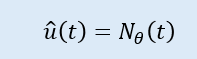

In [1]:
import geopandas as gpd
import pandas as pd
import os
import glob

In [2]:
def transform_for_network_prediction(file_path):  
    gdf = gpd.read_file(file_path)

    # columnas que NO son fechas
    fixed_cols = ["X", "Y"]  # si quieres puedes añadir "temporalCo", "coherence"
    drop_cols = ["temporalCo","coherence","geometry"]  # si quieres eliminar columnas específicas, añádelas aquí

    # todas las demás las tratamos como fechas
    date_cols = [c for c in gdf.columns if c not in fixed_cols and c not in drop_cols]

    df_long = gdf.melt(
        id_vars=fixed_cols,      # columnas que se mantienen (X,Y)
        value_vars=date_cols,    # columnas que se desdoblan (fechas)
        var_name="t",            # nueva columna para el tiempo
        value_name="u"           # nueva columna para la deformación
    )

    # pasar t de string tipo "20220223" a datetime
    df_long["t_datetime"] = pd.to_datetime(df_long["t"], format="%Y%m%d")

    # definir t0 como la primera fecha
    t0 = df_long["t_datetime"].min()

    # tiempo en días desde t0
    df_long["t_days"] = (df_long["t_datetime"] - t0).dt.days.astype(float)

    df_pinn = df_long[["X", "Y","t_datetime", "t_days", "u"]].copy()



    return df_pinn

In [ ]:
folder_input = r"C:\Users\julia\MGEO\THESIS\DEFORMATION_DATA\culstered_landslides_xy"

shp_files = glob.glob(f"{folder_input}\\*.shp")

In [22]:
shp_files

['C:\\Users\\julia\\MGEO\\THESIS\\DEFORMATION_DATA\\sub_culstered_landslides_xy\\CanteraBello1.shp',
 'C:\\Users\\julia\\MGEO\\THESIS\\DEFORMATION_DATA\\sub_culstered_landslides_xy\\MedellinOriental1.shp']

In [23]:
folder_output = r"C:\Users\julia\MGEO\THESIS\DEFORMATION_DATA\sub_culstered_landslides_xy\for_NN_prediction"

In [3]:
out = transform_for_network_prediction(r"C:/Users/julia/MGEO/THESIS/DEFORMATION_DATA/culstered_landslides_xy/BelloOeste.shp")

In [4]:
out.head()

,X,Y,t_datetime,t_days,u
0,4.714828e+06,2.260723e+06,2022-02-23,0.0,0.0
1,4.714828e+06,2.260683e+06,2022-02-23,0.0,0.0
2,4.714788e+06,2.260643e+06,2022-02-23,0.0,0.0
3,4.714828e+06,2.260643e+06,2022-02-23,0.0,0.0
4,4.714868e+06,2.260643e+06,2022-02-23,0.0,0.0


In [5]:
out.shape

(1300, 5)